# Telco Customer Churn — Exploratory Analysis & Prediction Model

**Goal:** figure out which customers are likely to churn and why, then build a model to flag at-risk customers early.

## 1. Importing the libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
import joblib

RANDOM_STATE = 42

## 2. Loading the dataset

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 7043, Columns: 21


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
suspect_rows = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

In [8]:
print(f"Rows where TotalCharges isn't a clean number: {len(suspect_rows)}")

Rows where TotalCharges isn't a clean number: 11


Checking these against tenure and the two charge columns to see what's going on.

In [9]:
suspect_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All 11 have `tenure = 0` — brand new signups with no bill yet. Filling with 0 makes sense.

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
# customerID should be unique
print(f"Unique customer IDs: {df['customerID'].nunique()} out of {len(df)} rows")

Unique customer IDs: 7043 out of 7043 rows


No duplicates, IDs are unique, missing values handled. Data's clean.

In [15]:
df = df.drop(columns=["customerID"])

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


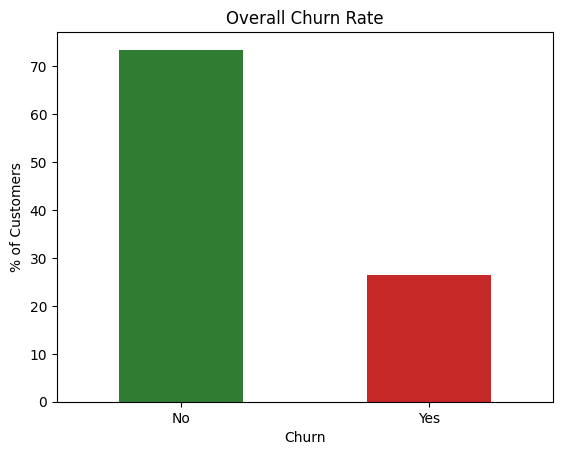

In [17]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate.round(2))

churn_rate.plot(kind="bar", color=["#2E7D32", "#C62828"])
plt.title("Overall Churn Rate")
plt.ylabel("% of Customers")
plt.xticks(rotation=0)
plt.show()

~26.5% churn overall — imbalanced classes (roughly 3:1), worth keeping in mind for modeling.

## 3. Exploring the data
Looking at who's actually churning and why.

### 3.1 Tenure

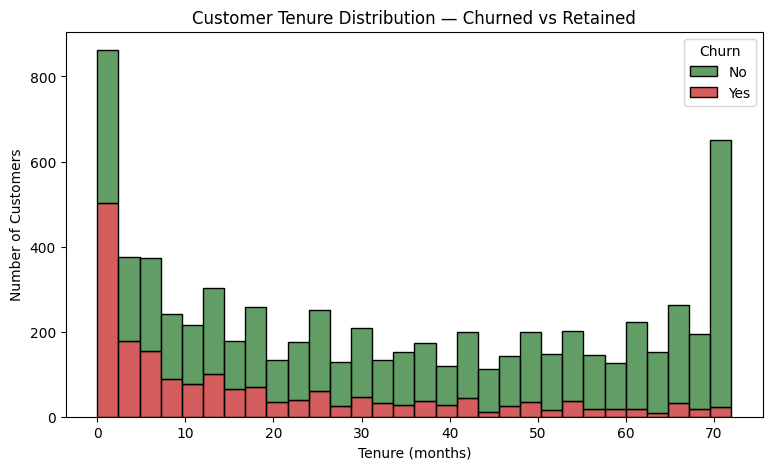

In [18]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30,
             palette={"No": "#2E7D32", "Yes": "#C62828"})
plt.title("Customer Tenure Distribution — Churned vs Retained")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

Churn is heavily front-loaded in the first few months, then drops off after ~1 year — likely an onboarding/early-experience issue.

### 3.2 Contract type

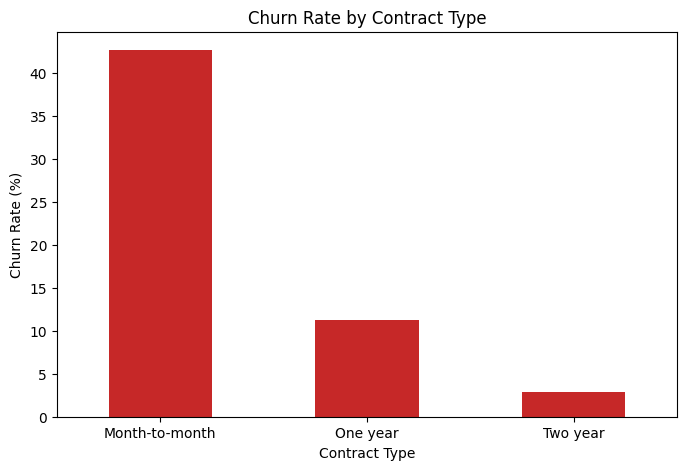

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


In [19]:
plt.figure(figsize=(8, 5))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn["Yes"].sort_values(ascending=False).plot(kind="bar", color="#C62828")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)
plt.show()

contract_churn.round(1)

Strongest signal in the dataset — month-to-month customers churn far more than annual/two-year holders, since there's no penalty for leaving.

### 3.3 Monthly charges

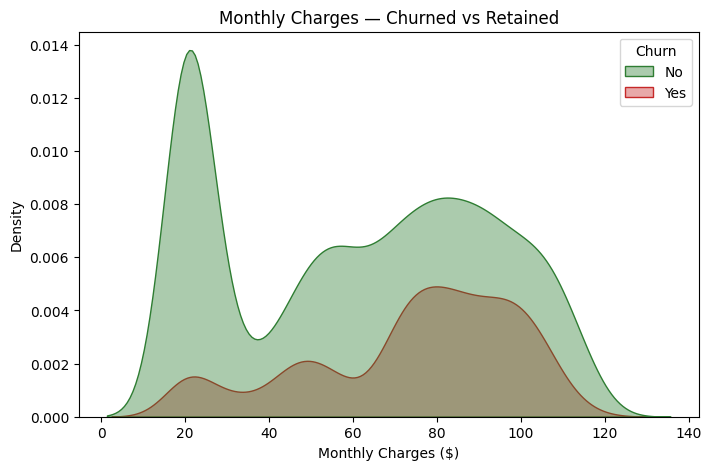

In [20]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True,
            palette={"No": "#2E7D32", "Yes": "#C62828"}, alpha=0.4)
plt.title("Monthly Charges — Churned vs Retained")
plt.xlabel("Monthly Charges ($)")
plt.show()

Churners skew toward higher monthly bills, though the gap isn't huge.

### 3.4 Internet service & add-ons

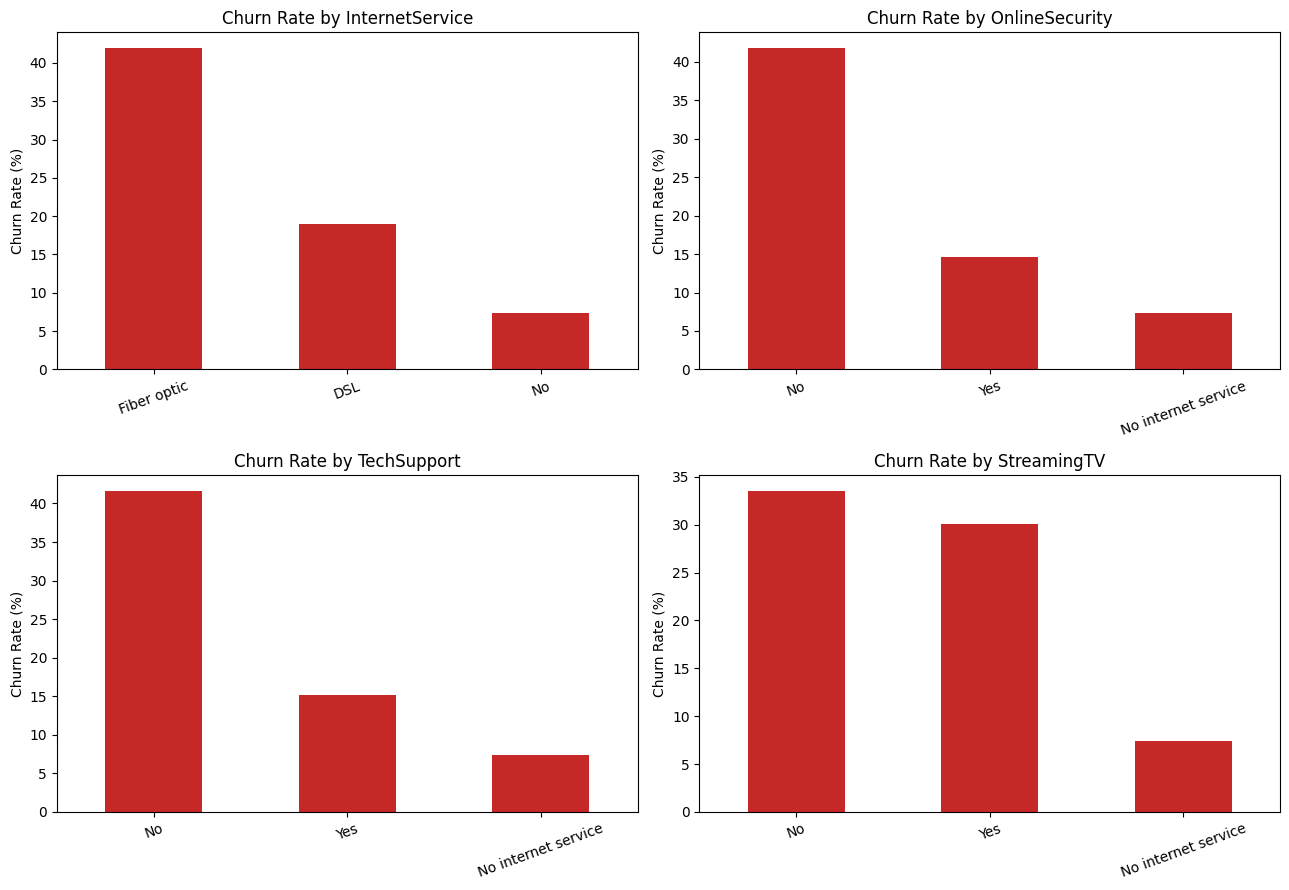

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
service_cols = ["InternetService", "OnlineSecurity", "TechSupport", "StreamingTV"]

for ax, col in zip(axes.flatten(), service_cols):
    rates = pd.crosstab(df[col], df["Churn"], normalize="index")["Yes"] * 100
    rates.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#C62828")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Fiber customers churn more than DSL despite being the 'better' product — possibly a price/quality gap. No security or tech support also correlates with higher churn; streaming TV barely moves the needle.

### 3.5 Payment method

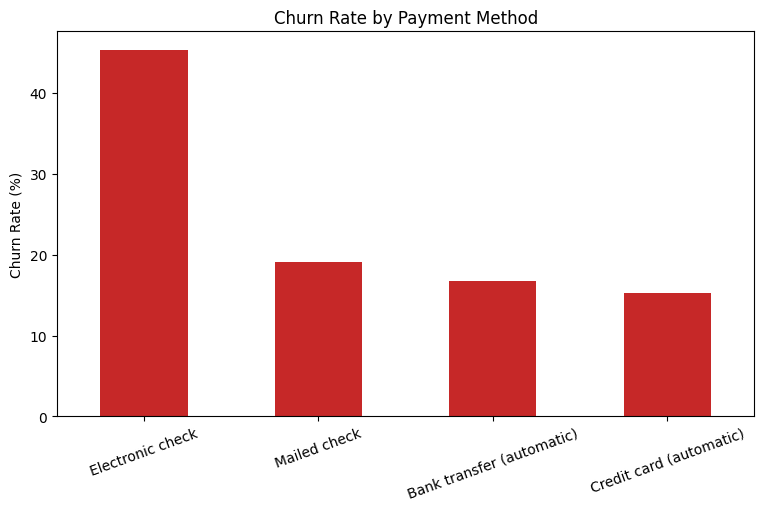

In [22]:
plt.figure(figsize=(9, 5))
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")["Yes"] * 100
payment_churn.sort_values(ascending=False).plot(kind="bar", color="#C62828")
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xlabel("")
plt.xticks(rotation=20)
plt.show()

Electronic check users churn noticeably more than customers on autopay (bank transfer/card) — friction-free billing seems to help retention.

### 3.6 Demographics

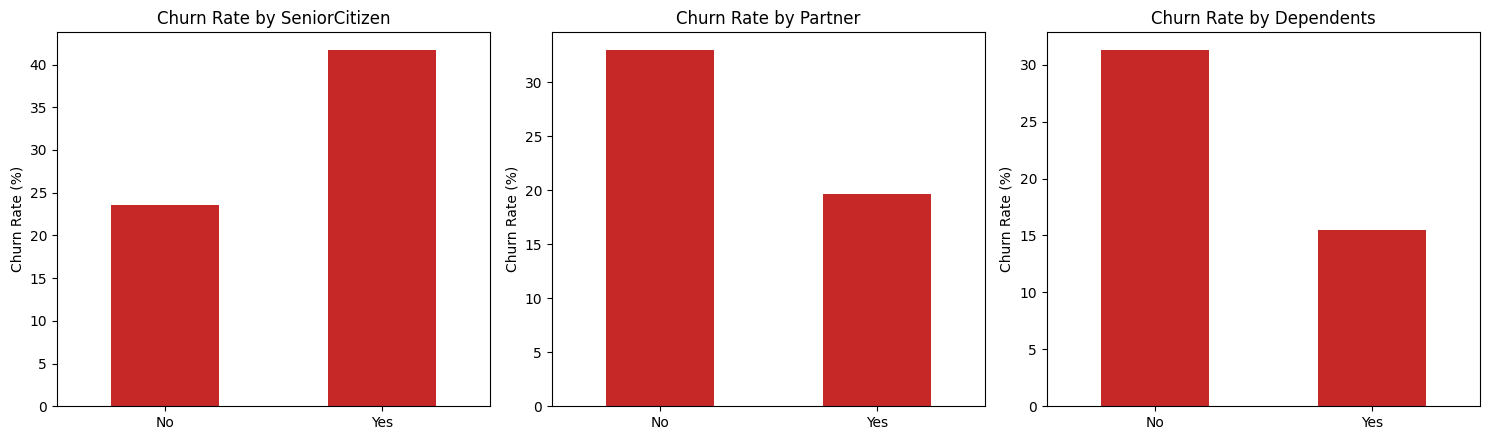

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
demo_cols = ["SeniorCitizen", "Partner", "Dependents"]

for ax, col in zip(axes, demo_cols):
    plot_df = df.copy()
    if col == "SeniorCitizen":
        plot_df[col] = plot_df[col].map({0: "No", 1: "Yes"})
    rates = pd.crosstab(plot_df[col], plot_df["Churn"], normalize="index")["Yes"] * 100
    rates.plot(kind="bar", ax=ax, color="#C62828")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Seniors, and customers without a partner or dependents, churn more — fewer household anchors means less friction to leave.

### 3.7 Correlation check

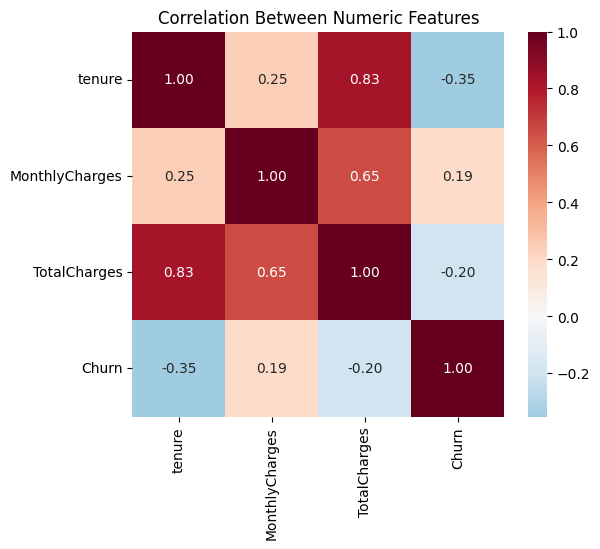

In [24]:
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
numeric_df["Churn"] = (df["Churn"] == "Yes").astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

Tenure is negatively correlated with churn, as expected; TotalCharges and tenure are tightly linked since one accumulates from the other.

## 4. Preparing the data for modeling

In [25]:
model_df = df.copy()

In [26]:
model_df["Churn"] = model_df["Churn"].map({"Yes": 1, "No": 0})

In [27]:
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
le = LabelEncoder()
# columns that are genuinely binary (2 categories) — safe to label encode
for col in binary_cols:
    model_df[col] = le.fit_transform(model_df[col])

In [28]:
# everything else with more than 2 categories -> one-hot encode
multi_cat_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                   "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                   "Contract", "PaymentMethod"]
model_df = pd.get_dummies(model_df, columns=multi_cat_cols, drop_first=True)

In [29]:
print(f"Shape after encoding: {model_df.shape}")
model_df.head()

Shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


### 4.1 Train/test split
80% train, 20% held out for testing.

In [30]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [32]:
print(f"Training rows: {X_train.shape[0]}, Test rows: {X_test.shape[0]}")
print(f"Churn rate in train: {y_train.mean():.3f}, Churn rate in test: {y_test.mean():.3f}")

Training rows: 5634, Test rows: 1409
Churn rate in train: 0.265, Churn rate in test: 0.265


### 4.2 Scaling

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Building and comparing models
- **Logistic Regression** — simple, interpretable baseline.
- **Decision Tree** — easy to explain, prone to overfitting alone.
- **Random Forest** — solid all-rounder for tabular data.
- **Gradient Boosting** — usually squeezes out extra performance.

In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE),
}

results = []

for name, model in models.items():
    # Logistic Regression benefits from scaled data, tree models don't need it
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df.sort_values("ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Gradient Boosting,0.801,0.662,0.508,0.575,0.844
Logistic Regression,0.807,0.658,0.567,0.609,0.842
Random Forest,0.804,0.666,0.527,0.588,0.841
Decision Tree,0.801,0.667,0.497,0.570,0.822


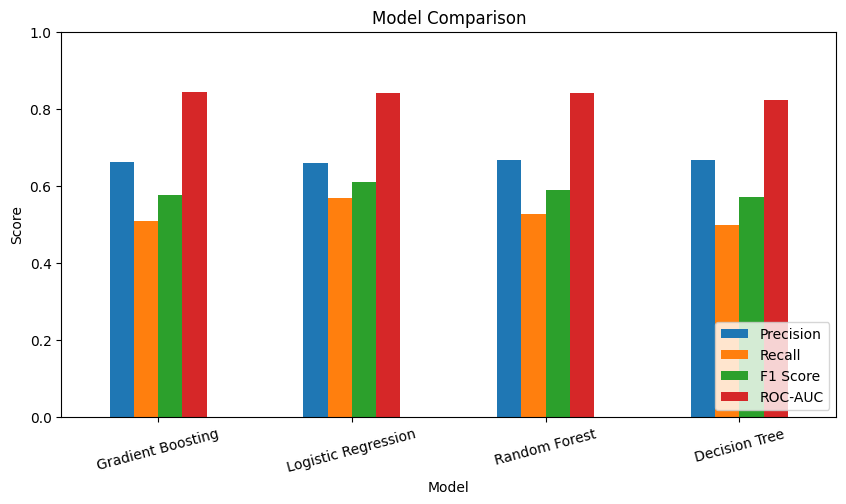

In [35]:
results_df.sort_values("ROC-AUC", ascending=False).plot(
    kind="bar", y=["Precision", "Recall", "F1 Score", "ROC-AUC"], figsize=(10, 5)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.ylim(0, 1)
plt.show()

Logistic Regression edges out the tree-based models on ROC-AUC here, and it's the most interpretable — tuning it further with GridSearchCV.

In [36]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated ROC-AUC: {grid.best_score_:.3f}")

final_model = grid.best_estimator_

Best parameters: {'C': 10, 'penalty': 'l2'}
Best cross-validated ROC-AUC: 0.846


## 6. Evaluating the final model

In [37]:
final_preds = final_model.predict(X_test_scaled)
final_probs = final_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, final_preds, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### 6.1 Confusion matrix

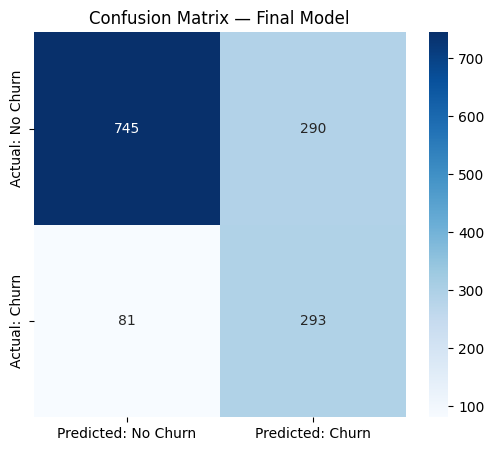

In [38]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: No Churn", "Predicted: Churn"],
            yticklabels=["Actual: No Churn", "Actual: Churn"])
plt.title("Confusion Matrix — Final Model")
plt.show()

### 6.2 ROC curve

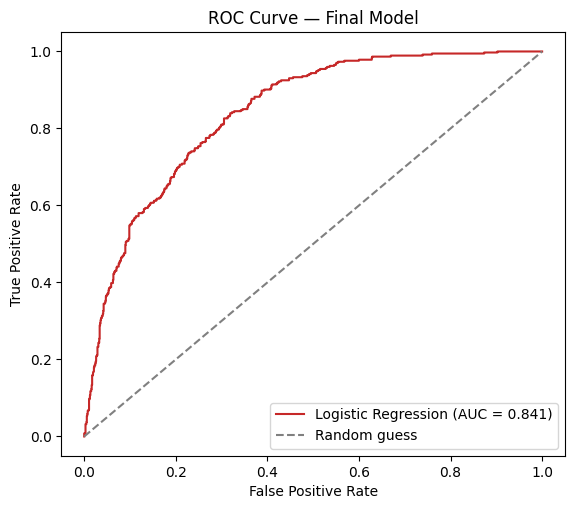

In [39]:
fpr, tpr, _ = roc_curve(y_test, final_probs)
auc_score = roc_auc_score(y_test, final_probs)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, color="#C62828", label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Model")
plt.legend(loc="lower right")
plt.show()

### 6.3 Feature impact

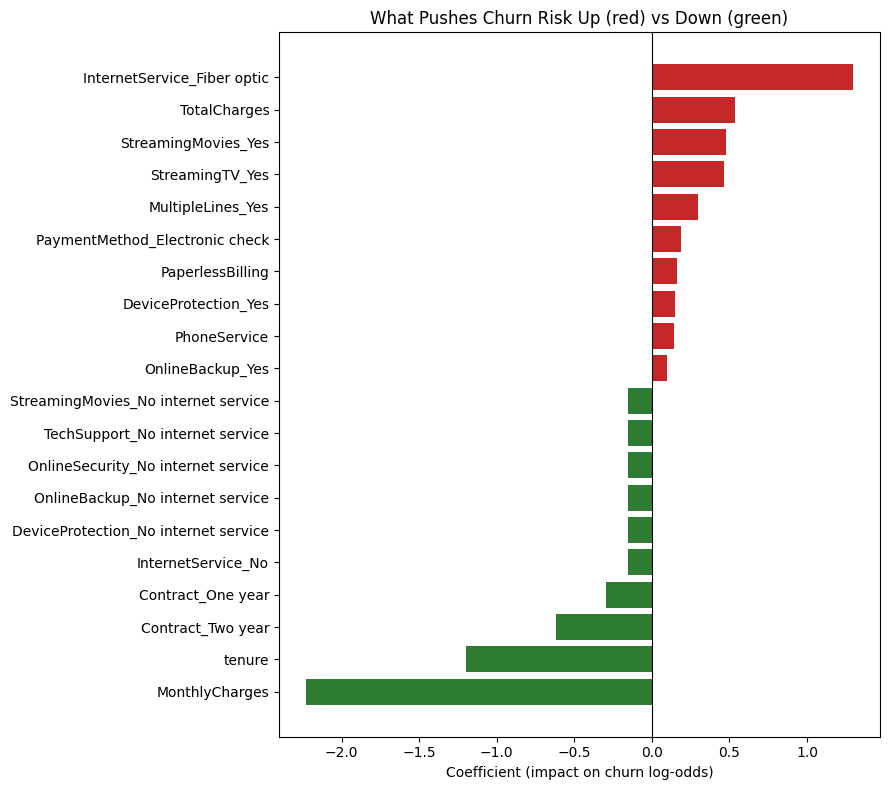

In [40]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": final_model.coef_[0]
}).sort_values("Coefficient")

# top 10 factors that REDUCE churn risk, and top 10 that INCREASE it
top_negative = coef_df.head(10)
top_positive = coef_df.tail(10)
top_features = pd.concat([top_negative, top_positive])

plt.figure(figsize=(9, 8))
colors = ["#2E7D32" if c < 0 else "#C62828" for c in top_features["Coefficient"]]
plt.barh(top_features["Feature"], top_features["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("What Pushes Churn Risk Up (red) vs Down (green)")
plt.xlabel("Coefficient (impact on churn log-odds)")
plt.tight_layout()
plt.show()

## 7. Wrapping up
Final model: Logistic Regression, tuned via GridSearchCV. Optimized for recall on the churn class since catching at-risk customers matters more than raw accuracy given the class imbalance. See the printed ROC-AUC above for the exact score.

In [41]:
artifact = {
    "model": final_model,
    "scaler": scaler,
    "feature_columns": list(X.columns),
    "binary_cols": binary_cols,
    "multi_cat_cols": multi_cat_cols,
}

In [42]:
joblib.dump(artifact, "../models/telco_churn_model.pkl")
print("Saved telco_churn_model.pkl")

Saved telco_churn_model.pkl


In [43]:
import joblib

artifact = joblib.load("../models/telco_churn_model.pkl")

print(artifact.keys())
print(type(artifact["model"]))
print(len(artifact["feature_columns"]))

dict_keys(['model', 'scaler', 'feature_columns', 'binary_cols', 'multi_cat_cols'])
<class 'sklearn.linear_model._logistic.LogisticRegression'>
30
